In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    "../data/cleaned_online_retail.csv"
)

In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 27.0 MB


# Exploratory Data Analysis (EDA)

This notebook analyzes customer purchasing behavior,
sales performance, products, countries,
and revenue trends.

In [5]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,392692.000000,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,2023-07-10 19:13:07.771893,3.125914,15287.843865,22.631500
min,536365.000000,1.000000,2022-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,2023-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,2023-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,2023-10-20 12:53:00,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,2023-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,13087.063759,180.492832,NaN,22.241836,1713.539549,311.099224


In [6]:
df.describe(include="object")

C:\Users\grava\AppData\Local\Temp\ipykernel_23136\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,StockCode,Description,Country
count,392692,392692,392692
unique,3665,3877,37
top,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,2023,2016,349203


In [7]:
df.nunique()

InvoiceNo      18532
StockCode       3665
Description     3877
Quantity         301
InvoiceDate    17282
UnitPrice        440
CustomerID      4338
Country           37
Revenue         2810
dtype: int64

Total Revenue

In [8]:
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 8,887,208.89


Total Orders

In [9]:
total_orders = df["InvoiceNo"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 18,532


Total Customers

In [10]:
total_customers = df["CustomerID"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 4,338


Total Products

In [11]:
total_products = df["Description"].nunique()

print(f"Total Products: {total_products:,}")

Total Products: 3,877


Countries Served

In [12]:
countries = df["Country"].nunique()

print(f"Countries Served: {countries}")

Countries Served: 37


Display All KPIs Together

In [13]:
print("="*40)
print("DATASET OVERVIEW")
print("="*40)

print(f"Total Revenue    : {df['Revenue'].sum():,.2f}")
print(f"Total Orders     : {df['InvoiceNo'].nunique():,}")
print(f"Total Customers  : {df['CustomerID'].nunique():,}")
print(f"Total Products   : {df['Description'].nunique():,}")
print(f"Countries Served : {df['Country'].nunique():,}")

DATASET OVERVIEW
Total Revenue    : 8,887,208.89
Total Orders     : 18,532
Total Customers  : 4,338
Total Products   : 3,877
Countries Served : 37


## Dataset Overview - Business Insights

- The company generated total revenue of 8.89 million.
- A total of 18,532 unique orders were placed.
- The customer base consists of 4,338 unique customers.
- The business sold 3,877 unique products.
- Products were sold across 37 countries.

These metrics indicate a large-scale international retail business with a diverse product catalog and customer base.

Calculate Revenue by Country

In [16]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

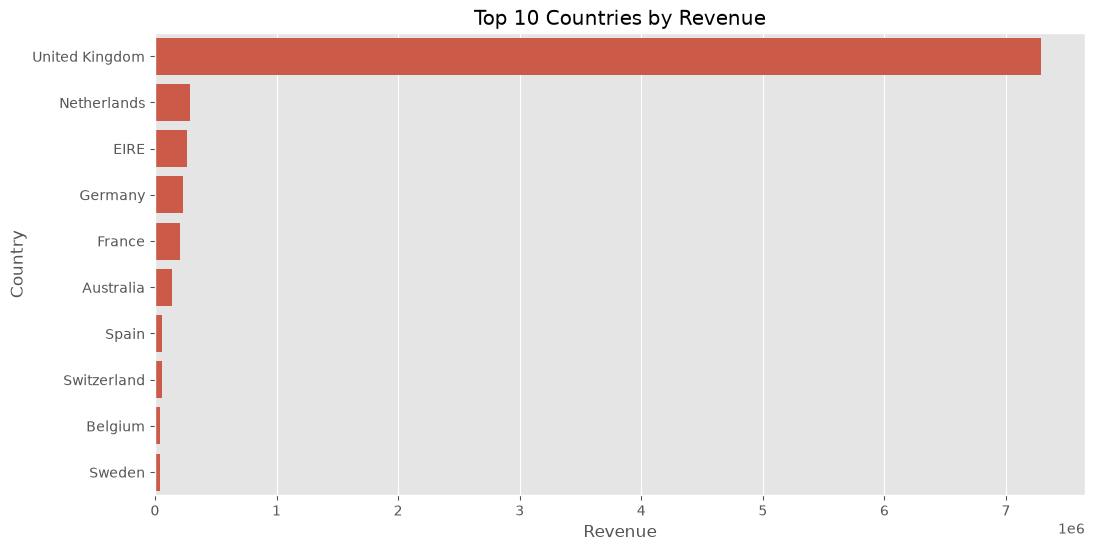

In [17]:
top10_country = country_sales.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10_country.values,
    y=top10_country.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.show()

## Observation

- United Kingdom contributes the highest revenue.
- A small number of countries contribute the majority of sales.
- Marketing efforts should focus on high-revenue countries.

Top Selling Products

In [18]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

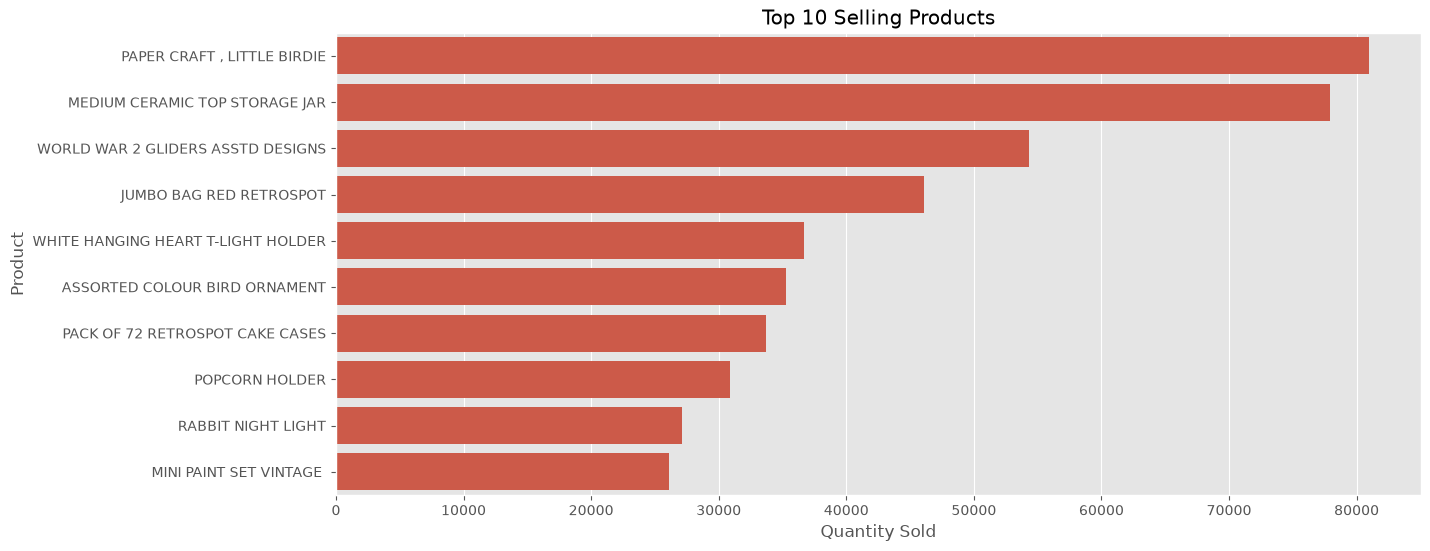

In [19]:
top10_products = top_products.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top10_products.values,
    y=top10_products.index
)

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

Monthly Revenue Trend

In [20]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [21]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

monthly_sales

Month
2022-12     570422.730
2023-01     568101.310
2023-02     446084.920
2023-03     594081.760
2023-04     468374.331
2023-05     677355.150
2023-06     660046.050
2023-07     598962.901
2023-08     644051.040
2023-09     950690.202
2023-10    1035642.450
2023-11    1156205.610
2023-12     517190.440
Freq: M, Name: Revenue, dtype: float64

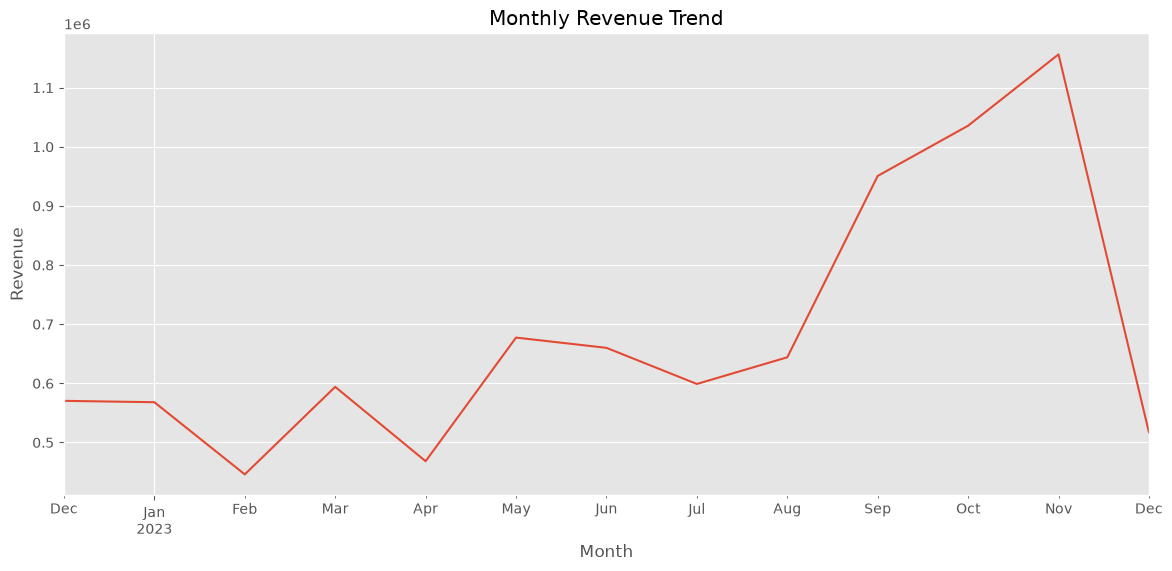

In [22]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Revenue Distribution

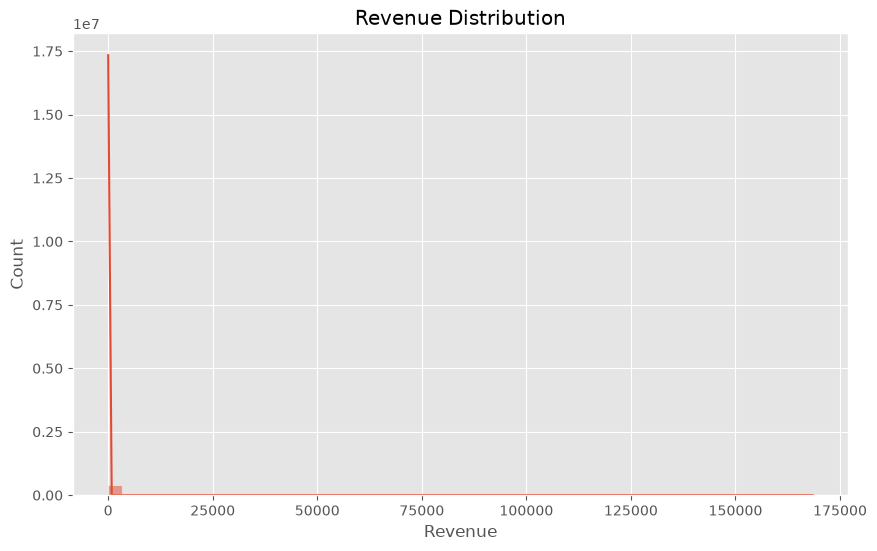

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Revenue"],
    bins=50,
    kde=True
)

plt.title("Revenue Distribution")

plt.show()

Top Customers

In [24]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

top_customers.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

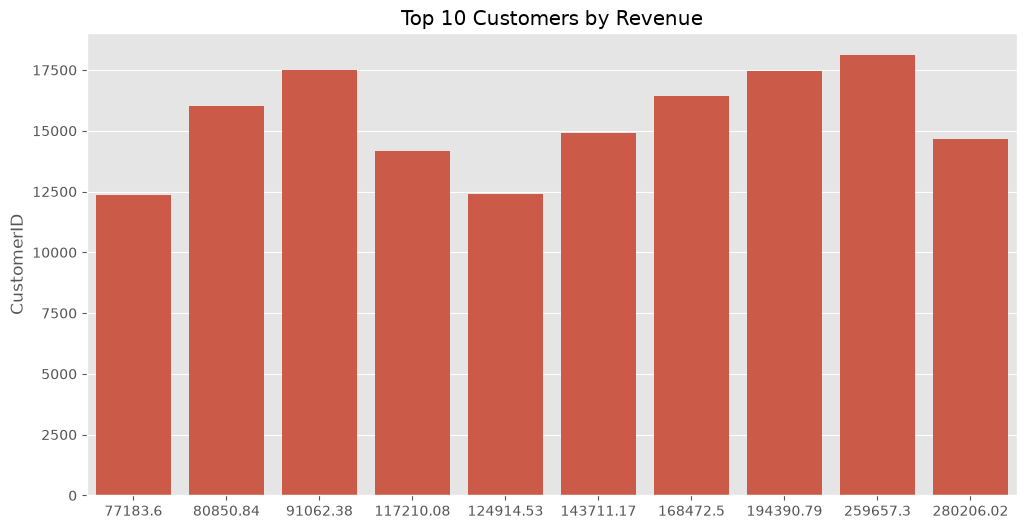

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.head(10).values,
    y=top_customers.head(10).index
)

plt.title("Top 10 Customers by Revenue")

plt.show()

Orders by Country

In [26]:
country_orders = (
    df.groupby("Country")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: InvoiceNo, dtype: int64

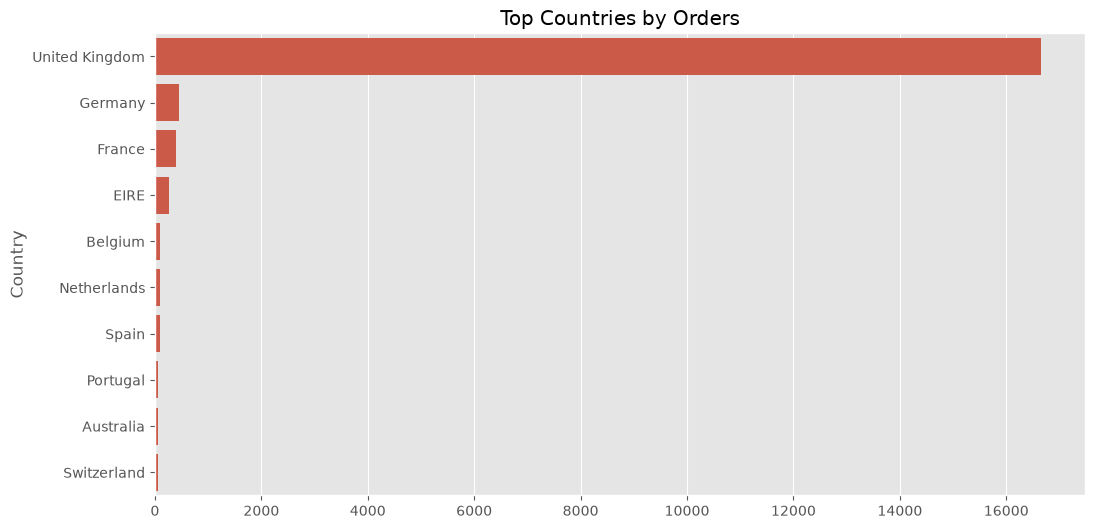

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_orders.head(10).values,
    y=country_orders.head(10).index
)

plt.title("Top Countries by Orders")

plt.show()